# Heart Reader: 12-Lead ECG Diagnostics
**Author:** Donyes Hsairi

## Summary
This notebook builds an end-to-end multi-modal deep learning pipeline capable of diagnosing 5 super-classes of cardiac pathologies from raw ECG signals and extracted features. 

## Pipeline Architecture
1. **Data Preprocessing:** Strict leakage prevention (Fold 1-8 Train, Fold 9 Val, Fold 10 Test).
2. **Intelligent Balancing:** Downsampling majority classes (NORM) and oversampling minority classes (HYP).
3. **Multi-Modal Fusion:** Combining 1D CNN embeddings (Inception/ResNet) with an MLP feature branch.
4. **Meta-Learner Ensemble:** Stacking probabilities using Logistic Regression CV to optimize F1/F2 thresholds.
5. **Deployment Readiness:** ONNX Graph compilation for latency < 2 seconds.

---

In [1]:
# =====================================================================
# CELL 1: Install Dependencies & Replicate Folder Architecture
# =====================================================================
# Install external packages now that Internet access is enabled
!pip install -q wfdb pyyaml scikit-learn pandas numpy matplotlib seaborn torch

import os
import sys
import random
import numpy as np
import pandas as pd
import torch

# Recreate the exact project directory structure inside Kaggle's workspace
os.makedirs("heart_reader/configs", exist_ok=True)
os.makedirs("heart_reader/data", exist_ok=True)
os.makedirs("heart_reader/models", exist_ok=True)
os.makedirs("heart_reader/training", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

# Strict determinism control matching the repo's reproducibility rules
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("✓ Environment initialized. Dependencies installed and seed 42 locked.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.0 MB/s eta 0:00:00
✓ Environment initialized. Dependencies installed and seed 42 locked.


In [2]:
# =====================================================================
# CELL 2: Replicate heart_reader/configs/default.yaml (15 EPOCHS)
# =====================================================================

default_yaml = """
data:
  ptbxl_path: "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"
  ptbxl_plus_path: "/kaggle/input/datasets/antonymgitau/ptb-xl-a-comprehensive-ecg-feature-dataset/ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1/"
  sampling_rate: 100

model:
  num_classes: 5
  num_features: 1313
  signal_embedding_dim: 256
  feature_embedding_dim: 64

training:
  batch_size: 64
  learning_rate: 0.001
  weight_decay: 0.01
  max_epochs: 100
  smoothing: 0.05
  alpha: 0.25
  gamma: 2.0
"""

with open("heart_reader/configs/default.yaml", "w") as f:
    f.write(default_yaml.strip())

print("✓ configs/default.yaml successfully written for 15 epochs.")

✓ configs/default.yaml successfully written for 15 epochs.


In [3]:
# =====================================================================
# CELL 3: Replicate heart_reader/data/preprocessing.py (FIXED ALIGNMENT)
# =====================================================================

preprocessing_py = """
import os
import ast
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

CLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def reduce_mem_usage(df):
    \"\"\"Iterates through all columns and downcasts float64 to float32 to save RAM.\"\"\"
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == np.float64:
            df[col] = df[col].astype(np.float32)
    return df

def load_and_preprocess_metadata(ptbxl_path):
    df_meta = pd.read_csv(os.path.join(ptbxl_path, "ptbxl_database.csv"))
    df_meta.scp_codes = df_meta.scp_codes.apply(lambda x: ast.literal_eval(x))
    
    df_scp = pd.read_csv(os.path.join(ptbxl_path, "scp_statements.csv"), index_col=0)
    df_scp_super = df_scp[df_scp.diagnostic_class.notnull()]
    
    for c in CLASSES:
        df_meta[c] = 0
        
    for idx, row in df_meta.iterrows():
        for code, likelihood in row['scp_codes'].items():
            if likelihood >= 50.0 and code in df_scp_super.index:
                super_c = df_scp_super.loc[code].diagnostic_class
                df_meta.at[idx, super_c] = 1
                
    return df_meta

def load_and_scale_features(ptbxl_plus_path, df_meta):
    df_12sl = pd.read_csv(os.path.join(ptbxl_plus_path, "features/12sl_features.csv"))
    df_deli = pd.read_csv(os.path.join(ptbxl_plus_path, "features/ecgdeli_features.csv"))
    
    # 1. Reduce memory immediately after loading
    df_12sl = reduce_mem_usage(df_12sl)
    df_deli = reduce_mem_usage(df_deli)
    
    df_feat = pd.merge(df_12sl, df_deli, on="ecg_id", suffixes=('_12sl', '_deli'))
    
    feature_cols = [c for c in df_feat.columns if c != 'ecg_id']
    
    # 2. Cast explicitly to float32 instead of float64 for memory efficiency
    df_feat[feature_cols] = df_feat[feature_cols].astype(np.float32)
    
    train_ecg_ids = df_meta[df_meta['strat_fold'] <= 8]['ecg_id']
    
    medians = df_feat[df_feat['ecg_id'].isin(train_ecg_ids)][feature_cols].median()
    df_feat[feature_cols] = df_feat[feature_cols].fillna(medians)
    
    scaler = StandardScaler()
    train_feat_mask = df_feat['ecg_id'].isin(train_ecg_ids)
    scaler.fit(df_feat[train_feat_mask][feature_cols])
    
    df_feat.loc[:, feature_cols] = scaler.transform(df_feat[feature_cols])
    
    # 3. Final memory cleanup
    df_feat = reduce_mem_usage(df_feat)
    return df_feat
"""

with open("heart_reader/data/preprocessing.py", "w") as f:
    f.write(preprocessing_py.strip())

print("✓ data/preprocessing.py rewritten with type casting and memory optimization.")

✓ data/preprocessing.py rewritten with type casting and memory optimization.


In [4]:
# =====================================================================
# CELL 4: Replicate heart_reader/data/dataset.py
# =====================================================================

dataset_py = """
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset
import wfdb

class ProductionMultiModalDataset(Dataset):
    def __init__(self, metadata_df, features_df, base_dir, lead_means=None, lead_stds=None, is_train=True):
        self.metadata = metadata_df.reset_index(drop=True)
        self.features = features_df.set_index('ecg_id')
        self.base_dir = base_dir
        
        # Store training statistics for the 12 leads
        self.lead_means = lead_means 
        self.lead_stds = lead_stds
        
        self.is_train = is_train
        self.classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
        
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        ecg_id = row['ecg_id']
        
        # 1. Load Raw Signal
        record_path = os.path.join(self.base_dir, row['filename_lr'])
        signal_data, _ = wfdb.rdsamp(record_path)
        signal = signal_data.astype(np.float32).T  # Shape: (12, 1000)
        
        # 2. Apply Independent Lead-Wise Normalization
        if self.lead_means is not None and self.lead_stds is not None:
            epsilon = 1e-8
            # Reshape stats to (12, 1) for broadcasting across the 1000 timesteps
            means = self.lead_means.reshape(12, 1).astype(np.float32)
            stds = self.lead_stds.reshape(12, 1).astype(np.float32)
            signal = (signal - means) / (stds + epsilon)
            
        features = self.features.loc[ecg_id].values.astype(np.float32)
        labels = row[self.classes].values.astype(np.float32)
        
        # 3. Apply Training Augmentations
        if self.is_train:
            # Standard Augmentations
            if random.random() < 0.4:
                signal += 0.03 * np.random.randn(*signal.shape).astype(np.float32)
            if random.random() < 0.4:
                signal *= random.uniform(0.85, 1.15)
                
            # Masked Training (1D Cutout)
            if random.random() < 0.3:
                num_leads, seq_len = signal.shape
                for i in range(num_leads):
                    if random.random() < 0.5:
                        mask_len = random.randint(50, seq_len // 4)
                        start_pos = random.randint(0, seq_len - mask_len)
                        signal[i, start_pos:start_pos + mask_len] = 0.0
                
        return torch.tensor(signal), torch.tensor(features), torch.tensor(labels)

    def __len__(self):
        return len(self.metadata)
"""

with open("heart_reader/data/dataset.py", "w") as f:
    f.write(dataset_py.strip())

print("✓ data/dataset.py successfully written with Independent Lead-Wise Normalization and 1D Cutout.")

✓ data/dataset.py successfully written with Independent Lead-Wise Normalization and 1D Cutout.


In [5]:
# =====================================================================
# CELL 5: Replicate heart_reader/models/heads.py and backbones.py
# =====================================================================

heads_py = """
import torch
import torch.nn as nn

class SqueezeExcitation1D(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        squeeze = x.mean(dim=-1)
        excitation = self.fc(squeeze).view(b, c, 1)
        return x * excitation
"""

with open("heart_reader/models/heads.py", "w") as f:
    f.write(heads_py.strip())

backbones_py = """
import torch
import torch.nn as nn
from models.heads import SqueezeExcitation1D

class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.b1 = nn.Conv1d(in_channels, out_channels, kernel_size=39, padding=19, bias=False)
        self.b2 = nn.Conv1d(in_channels, out_channels, kernel_size=19, padding=9, bias=False)
        self.b3 = nn.Conv1d(in_channels, out_channels, kernel_size=9, padding=4, bias=False)
        self.bn = nn.BatchNorm1d(out_channels * 3)
        self.se = SqueezeExcitation1D(out_channels * 3)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        out = torch.cat([self.b1(x), self.b2(x), self.b3(x)], dim=1)
        return self.relu(self.se(self.bn(out)))

class SEResNetBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.se = SqueezeExcitation1D(out_channels)
        self.downsample = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_channels)
        ) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.se(self.bn2(self.conv2(out)))
        out += identity
        return self.relu(out)

class XResNetBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.pool = nn.AvgPool1d(2, stride=1, padding=0)
        self.downsample = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_channels)
        ) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)
"""

with open("heart_reader/models/backbones.py", "w") as f:
    f.write(backbones_py.strip())

print("✓ Core structural sub-modules (Inception, SE-ResNet, XResNet) successfully written.")

✓ Core structural sub-modules (Inception, SE-ResNet, XResNet) successfully written.


In [6]:
# =====================================================================
# CELL 6: Replicate heart_reader/models/fusion_model.py and training/losses.py
# =====================================================================

fusion_model_py = """
import torch
import torch.nn as nn
from models.backbones import InceptionBlock1D, SEResNetBlock1D, XResNetBlock1D

class HeartReaderFusionModel(nn.Module):
    def __init__(self, backbone_name="inception1d", num_classes=5, num_features=1313):
        super().__init__()
        self.stem = nn.Conv1d(12, 32, kernel_size=7, padding=3, bias=False)
        
        if backbone_name == "inception1d":
            self.block1 = InceptionBlock1D(32, 32)
            self.block2 = InceptionBlock1D(96, 64)
            sig_dim = 192
        elif backbone_name == "se_resnet1d":
            self.block1 = SEResNetBlock1D(32, 32)
            self.block2 = SEResNetBlock1D(32, 64)
            sig_dim = 64
        elif backbone_name == "xresnet1d101":
            self.block1 = XResNetBlock1D(32, 32)
            self.block2 = XResNetBlock1D(32, 64)
            sig_dim = 64
        else:
            raise ValueError("Backbone not supported")
            
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.signal_dense = nn.Sequential(
            nn.Linear(sig_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4)
        )
        
        self.feature_mlp = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True)
        )
        
        self.head = nn.Sequential(
            nn.Linear(256 + 64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, signal, features):
        sig_x = self.stem(signal)
        sig_x = self.block1(sig_x)
        sig_x = self.block2(sig_x)
        sig_x = self.pool(sig_x).squeeze(-1)
        sig_embed = self.signal_dense(sig_x)
        
        feat_embed = self.feature_mlp(features)
        
        fused = torch.cat([sig_embed, feat_embed], dim=1)
        return self.head(fused)
"""

with open("heart_reader/models/fusion_model.py", "w") as f:
    f.write(fusion_model_py.strip())

losses_py = """
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLossWithLabelSmoothing(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        
    def forward(self, logits, targets):
        smoothed_targets = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
        bce_loss = F.binary_cross_entropy_with_logits(logits, smoothed_targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
        focal_weight = (1.0 - p_t) ** self.gamma
        loss = focal_weight * bce_loss
        
        if self.alpha >= 0:
            alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
            loss = alpha_t * loss
            
        return loss.mean()
"""

with open("heart_reader/training/losses.py", "w") as f:
    f.write(losses_py.strip())

print("✓ Dynamic Fusion architecture and Focal Loss engine configured.")

✓ Dynamic Fusion architecture and Focal Loss engine configured.


In [7]:
# =====================================================================
# CELL 7: Replicate heart_reader/train.py (ONE-CYCLE & ARGPARSE)
# =====================================================================

train_py = """
import os
import sys
import yaml
import argparse
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

sys.path.append(os.path.abspath(os.path.dirname(__file__)))
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

from data.preprocessing import load_and_preprocess_metadata, load_and_scale_features
from data.dataset import ProductionMultiModalDataset
from models.fusion_model import HeartReaderFusionModel
from training.losses import FocalLossWithLabelSmoothing

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--backbone", type=str, default="inception1d")
    args = parser.parse_args()
    
    with open("configs/default.yaml", "r") as f:
        config = yaml.safe_load(f)
        
    print(f"--- Loading and Standardizing Data Layers for: {args.backbone} ---")
    df_meta = load_and_preprocess_metadata(config['data']['ptbxl_path'])
    df_feat = load_and_scale_features(config['data']['ptbxl_plus_path'], df_meta)
    
    valid_ids = np.intersect1d(df_meta['ecg_id'].values, df_feat['ecg_id'].values)
    df_meta = df_meta[df_meta['ecg_id'].isin(valid_ids)]
    
    train_df = df_meta[df_meta['strat_fold'] <= 8]
    val_df = df_meta[df_meta['strat_fold'] == 9]
    
    train_dataset = ProductionMultiModalDataset(train_df, df_feat, config['data']['ptbxl_path'], is_train=True)
    val_dataset = ProductionMultiModalDataset(val_df, df_feat, config['data']['ptbxl_path'], is_train=False)
    
    train_loader = DataLoader(train_dataset, batch_size=config['training']['batch_size'], shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=config['training']['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = HeartReaderFusionModel(backbone_name=args.backbone, num_classes=config['model']['num_classes'], num_features=config['model']['num_features']).to(device)
    
    criterion = FocalLossWithLabelSmoothing(alpha=config['training']['alpha'], gamma=config['training']['gamma'], smoothing=config['training']['smoothing'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['training']['learning_rate'], weight_decay=config['training']['weight_decay'])
    
    # ONE-CYCLE LEARNING RATE SCHEDULER
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config['training']['learning_rate'],
        steps_per_epoch=len(train_loader),
        epochs=config['training']['max_epochs'],
        pct_start=0.3,
        div_factor=25.0,
        final_div_factor=1000.0
    )
    
    print(f"Beginning One-Cycle training loop on device: {device}")
    metrics_log = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    best_val_auc = 0.0
    
    for epoch in range(1, config['training']['max_epochs'] + 1):
        model.train()
        running_loss = 0.0
        for sigs, feats, labels in train_loader:
            sigs, feats, labels = sigs.to(device), feats.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(sigs, feats)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step() # Step scheduler per batch
            running_loss += loss.item() * sigs.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for sigs, feats, labels in val_loader:
                sigs, feats, labels = sigs.to(device), feats.to(device), labels.to(device)
                logits = model(sigs, feats)
                loss = criterion(logits, labels)
                val_loss += loss.item() * sigs.size(0)
                val_preds.append(torch.sigmoid(logits).cpu().numpy())
                val_targets.append(labels.cpu().numpy())
                
        val_loss /= len(val_loader.dataset)
        val_preds = np.vstack(val_preds)
        val_targets = np.vstack(val_targets)
        val_auc = roc_auc_score(val_targets, val_preds, average='macro')
        
        metrics_log['train_loss'].append(epoch_loss)
        metrics_log['val_loss'].append(val_loss)
        metrics_log['val_auc'].append(val_auc)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch:02d}/{config['training']['max_epochs']}] -> LR: {current_lr:.6f} | Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), f"../checkpoints/fusion_{args.backbone}_best.pt")
            
    pd.DataFrame(metrics_log).to_csv(f"../checkpoints/{args.backbone}_history.csv", index=False)

if __name__ == "__main__":
    main()
"""

with open("heart_reader/train.py", "w") as f:
    f.write(train_py.strip())

print("✓ main orchestrator rewritten with Multi-Backbone and One-Cycle support.")

✓ main orchestrator rewritten with Multi-Backbone and One-Cycle support.


In [8]:
# =====================================================================
# CELLULE 7.5: DATALOADER INITIALIZATION & INTELLIGENT BALANCING
# =====================================================================
import os
import sys
import yaml
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import importlib

# 1. On récupère le chemin exact de votre dossier
chemin_absolu = os.path.abspath("heart_reader")
if chemin_absolu not in sys.path:
    sys.path.insert(0, chemin_absolu)

# 2. Création du fichier __init__.py 
os.makedirs(os.path.join(chemin_absolu, "data"), exist_ok=True)
with open(os.path.join(chemin_absolu, "data", "__init__.py"), "w") as f:
    pass

# 3. LE SECRET : On force Python à oublier ses anciennes erreurs d'import !
importlib.invalidate_caches()
for key in list(sys.modules.keys()):
    if key.startswith('data'):
        del sys.modules[key]

# 4. Maintenant l'import va fonctionner parfaitement
from data.preprocessing import load_and_preprocess_metadata, load_and_scale_features
from data.dataset import ProductionMultiModalDataset

# Load paths from your config
with open("heart_reader/configs/default.yaml", "r") as f:
    config = yaml.safe_load(f)

ptbxl_path = config['data'].get('ptbxl_path')
ptbxl_plus_path = config['data'].get('ptbxl_plus_path')

print("--- Initializing DataFrames and generating DataLoaders (this takes a minute)... ---")
df_meta = load_and_preprocess_metadata(ptbxl_path)
df_feat = load_and_scale_features(ptbxl_plus_path, df_meta)

valid_ids = np.intersect1d(df_meta['ecg_id'].values, df_feat['ecg_id'].values)
df_meta = df_meta[df_meta['ecg_id'].isin(valid_ids)]

# Split folds exactly like your training script requires
train_df = df_meta[df_meta['strat_fold'] <= 8].copy()
val_df = df_meta[df_meta['strat_fold'] == 9].copy()
test_df = df_meta[df_meta['strat_fold'] == 10].copy()

# =====================================================================
# INTELLIGENT CLASS BALANCING
# =====================================================================
# Downsample pure NORM to 4000 (prevents dropping multi-label minority classes)
pure_norm_mask = (train_df['NORM'] == 1) & (train_df['MI'] == 0) & (train_df['STTC'] == 0) & (train_df['CD'] == 0) & (train_df['HYP'] == 0)
norm_idx = train_df[pure_norm_mask].index

if len(norm_idx) > 4000:
    norm_to_drop = np.random.choice(norm_idx, size=len(norm_idx) - 4000, replace=False)
    train_df = train_df.drop(norm_to_drop)

# Oversample HYP to 4000
hyp_current = train_df[train_df['HYP'] == 1]
if len(hyp_current) < 4000:
    hyp_to_add = hyp_current.sample(n=4000 - len(hyp_current), replace=True, random_state=42)
    train_df = pd.concat([train_df, hyp_to_add])

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✓ Dataset intelligently balanced! New Training Size: {len(train_df)} samples.")
# =====================================================================

train_dataset = ProductionMultiModalDataset(train_df, df_feat, ptbxl_path, is_train=True)
val_dataset = ProductionMultiModalDataset(val_df, df_feat, ptbxl_path, is_train=False)
test_dataset = ProductionMultiModalDataset(test_df, df_feat, ptbxl_path, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=config['training']['batch_size'], shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=config['training']['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config['training']['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

# Generate Class Weights Dynamically based on the new balanced distribution
class_counts = torch.tensor([train_df[c].sum() for c in ['NORM', 'MI', 'STTC', 'CD', 'HYP']], dtype=torch.float32)
total_samples = class_counts.sum()
class_weights = total_samples / (len(class_counts) * class_counts)

print("✓ SUCCESS: train_loader, val_loader, test_loader, and dynamic class_weights are now in memory!")

--- Initializing DataFrames and generating DataLoaders (this takes a minute)... ---
✓ Dataset intelligently balanced! New Training Size: 16373 samples.
✓ SUCCESS: train_loader, val_loader, test_loader, and dynamic class_weights are now in memory!


In [9]:
# =====================================================================
# CELL 8: ENTRAÎNEMENT AVANCÉ (Attention + SE + SWT + Curriculum)
# =====================================================================
!pip install -q PyWavelets

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import pywt
import sys
import os
import gc

sys.path.insert(0, os.path.abspath("heart_reader"))

# ---------- 1. Fusion Model with Multi-Head Attention & SE ----------
class HeartReaderFusionModelWithAttention(nn.Module):
    def __init__(self, backbone_name="inception1d", num_classes=5, num_features=1313):
        super().__init__()
        self.stem = nn.Conv1d(12, 32, kernel_size=7, padding=3, bias=False)
        
        if backbone_name == "inception1d":
            from models.backbones import InceptionBlock1D
            self.block1 = InceptionBlock1D(32, 32)
            self.block2 = InceptionBlock1D(96, 64)
            sig_dim = 192
        elif backbone_name == "se_resnet1d":
            from models.backbones import SEResNetBlock1D
            self.block1 = SEResNetBlock1D(32, 32)
            self.block2 = SEResNetBlock1D(32, 64)
            sig_dim = 64
        elif backbone_name == "xresnet1d101":
            from models.backbones import XResNetBlock1D
            self.block1 = XResNetBlock1D(32, 32)
            self.block2 = XResNetBlock1D(32, 64)
            sig_dim = 64
        else:
            raise ValueError("Backbone not supported")
        
        # Standard Multi-Head Attention
        self.attention = nn.MultiheadAttention(embed_dim=sig_dim, num_heads=4, batch_first=True)
        self.attn_norm = nn.LayerNorm(sig_dim)
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        self.signal_dense = nn.Sequential(
            nn.Linear(sig_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4)
        )
        
        self.feature_mlp = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True)
        )
        
        self.head = nn.Sequential(
            nn.Linear(256 + 64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, signal, features):
        x = self.stem(signal)
        x = self.block1(x)
        x = self.block2(x)
        
        # Multi-Head Attention expects (Batch, Seq_Len, Channels) when batch_first=True
        x = x.permute(0, 2, 1)
        attn_out, _ = self.attention(x, x, x)
        x = self.attn_norm(x + attn_out)
        
        # Back to (Batch, Channels, Seq_Len) for pooling
        x = x.permute(0, 2, 1)
        
        x = self.pool(x).squeeze(-1)       
        sig_embed = self.signal_dense(x)
        
        feat_embed = self.feature_mlp(features)
        fused = torch.cat([sig_embed, feat_embed], dim=1)
        return self.head(fused)

# ---------- 2. SWT Augmentation & Curriculum ----------
def swt_augment_batch(sigs, p=0.4, wavelet='db4', level=3, noise_std=0.02):
    aug_sigs = sigs.clone()
    B, C, L = aug_sigs.shape
    if torch.rand(1).item() > p:
        return aug_sigs
    
    for b in range(B):
        for c in range(C):
            sig_np = aug_sigs[b, c, :].cpu().numpy()
            coeffs = pywt.swt(sig_np, wavelet, level=level)
            modified_coeffs = []
            for i, (approx, detail) in enumerate(coeffs):
                noise = np.random.randn(*detail.shape) * noise_std * (i+1) * 0.5
                modified_coeffs.append((approx, detail + noise))
            reconstructed = pywt.iswt(modified_coeffs, wavelet)
            if len(reconstructed) > L:
                reconstructed = reconstructed[:L]
            elif len(reconstructed) < L:
                reconstructed = np.pad(reconstructed, (0, L - len(reconstructed)), mode='constant')
            aug_sigs[b, c, :] = torch.tensor(reconstructed, dtype=torch.float32)
    return aug_sigs.to(sigs.device)

class CurriculumScheduler:
    def __init__(self, initial_noise=0.01, max_noise=0.05, initial_p=0.3, max_p=0.6):
        self.initial_noise = initial_noise
        self.max_noise = max_noise
        self.initial_p = initial_p
        self.max_p = max_p
    
    def get_params(self, epoch, total_epochs):
        progress = epoch / total_epochs
        noise = self.initial_noise + (self.max_noise - self.initial_noise) * progress
        p = self.initial_p + (self.max_p - self.initial_p) * progress
        return noise, p

class ClassWeightedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = (1 - pt) ** self.gamma * bce_loss

        if self.alpha is not None:
            alpha = self.alpha.to(targets.device)
            weight = targets * alpha + (1 - targets) * 1.0
            focal_loss = focal_loss * weight
        return focal_loss.mean()

# ---------- 3. Training Loop ----------
def train_one_epoch(model, loader, criterion, optimizer, scheduler, device, curriculum, epoch, total_epochs):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    noise_std, aug_p = curriculum.get_params(epoch, total_epochs)
    
    for sigs, feats, labels in loader:
        sigs, feats, labels = sigs.to(device), feats.to(device), labels.to(device)
        sigs = swt_augment_batch(sigs, p=aug_p, noise_std=noise_std)
        
        optimizer.zero_grad()
        outputs = model(sigs, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        running_loss += loss.item() * sigs.size(0)
        all_preds.append(torch.sigmoid(outputs).detach().cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    
    return running_loss / len(loader.dataset), roc_auc_score(np.vstack(all_labels), np.vstack(all_preds), average='macro')

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sigs, feats, labels in loader:
            sigs, feats, labels = sigs.to(device), feats.to(device), labels.to(device)
            outputs = model(sigs, feats)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * sigs.size(0)
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            
    return running_loss / len(loader.dataset), roc_auc_score(np.vstack(all_labels), np.vstack(all_preds), average='macro')

# ---------- 4. Main Execution ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

backbones = ["inception1d", "se_resnet1d", "xresnet1d101"]
num_epochs = 50
patience = 8

curriculum = CurriculumScheduler(initial_noise=0.01, max_noise=0.05, initial_p=0.3, max_p=0.6)
os.makedirs("checkpoints", exist_ok=True)

for bb in backbones:
    print(f"\n{'='*60}\nTraining with Attention Backbone: {bb.upper()}\n{'='*60}")
    
    model = HeartReaderFusionModelWithAttention(backbone_name=bb, num_classes=5, num_features=1313)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model = model.to(device)
    
    # Assuming class_weights is defined previously in your notebook (e.g. Cell 7.5)
    criterion = ClassWeightedFocalLoss(alpha=class_weights, gamma=2.5)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.0003, steps_per_epoch=len(train_loader),
        epochs=num_epochs, pct_start=0.3, div_factor=25.0, final_div_factor=1000.0
    )
    
    best_val_auc = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
    
    for epoch in range(1, num_epochs + 1):
        train_loss, train_auc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device, curriculum, epoch, num_epochs)
        val_loss, val_auc = validate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)
        torch.save(history, f"checkpoints/history_{bb}.pt")
        
        print(f"Epoch [{epoch:02d}/{num_epochs}] -> LR: {optimizer.param_groups[0]['lr']:.6f} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} || Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}")
        
        if val_auc > best_val_auc:
            print(f"   [+] New best validation AUC: {val_auc:.4f} (saving)")
            best_val_auc = val_auc
            epochs_no_improve = 0
            torch.save(model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(), f"checkpoints/fusion_{bb}_best.pt")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"   [!] Early stopping at epoch {epoch}.")
                break
                
    # --- MEMORY CLEANUP: Prevent CUDA OOM between model trainings ---
    del model
    del optimizer
    del scheduler
    gc.collect()
    torch.cuda.empty_cache() 

print("\nTraining complete!")

Using device: cuda

Training with Attention Backbone: INCEPTION1D
Epoch [01/50] -> LR: 0.000015 | Train Loss: 0.1569 | Val Loss: 0.0946 || Train AUC: 0.6478 | Val AUC: 0.8424
   [+] New best validation AUC: 0.8424 (saving)
Epoch [02/50] -> LR: 0.000024 | Train Loss: 0.1225 | Val Loss: 0.0781 || Train AUC: 0.7454 | Val AUC: 0.8772
   [+] New best validation AUC: 0.8772 (saving)
Epoch [03/50] -> LR: 0.000040 | Train Loss: 0.0994 | Val Loss: 0.0628 || Train AUC: 0.7935 | Val AUC: 0.8952
   [+] New best validation AUC: 0.8952 (saving)
Epoch [04/50] -> LR: 0.000060 | Train Loss: 0.0861 | Val Loss: 0.0583 || Train AUC: 0.8261 | Val AUC: 0.9076
   [+] New best validation AUC: 0.9076 (saving)
Epoch [05/50] -> LR: 0.000084 | Train Loss: 0.0779 | Val Loss: 0.0561 || Train AUC: 0.8545 | Val AUC: 0.9155
   [+] New best validation AUC: 0.9155 (saving)
Epoch [06/50] -> LR: 0.000112 | Train Loss: 0.0712 | Val Loss: 0.0541 || Train AUC: 0.8772 | Val AUC: 0.9189
   [+] New best validation AUC: 0.9189 (

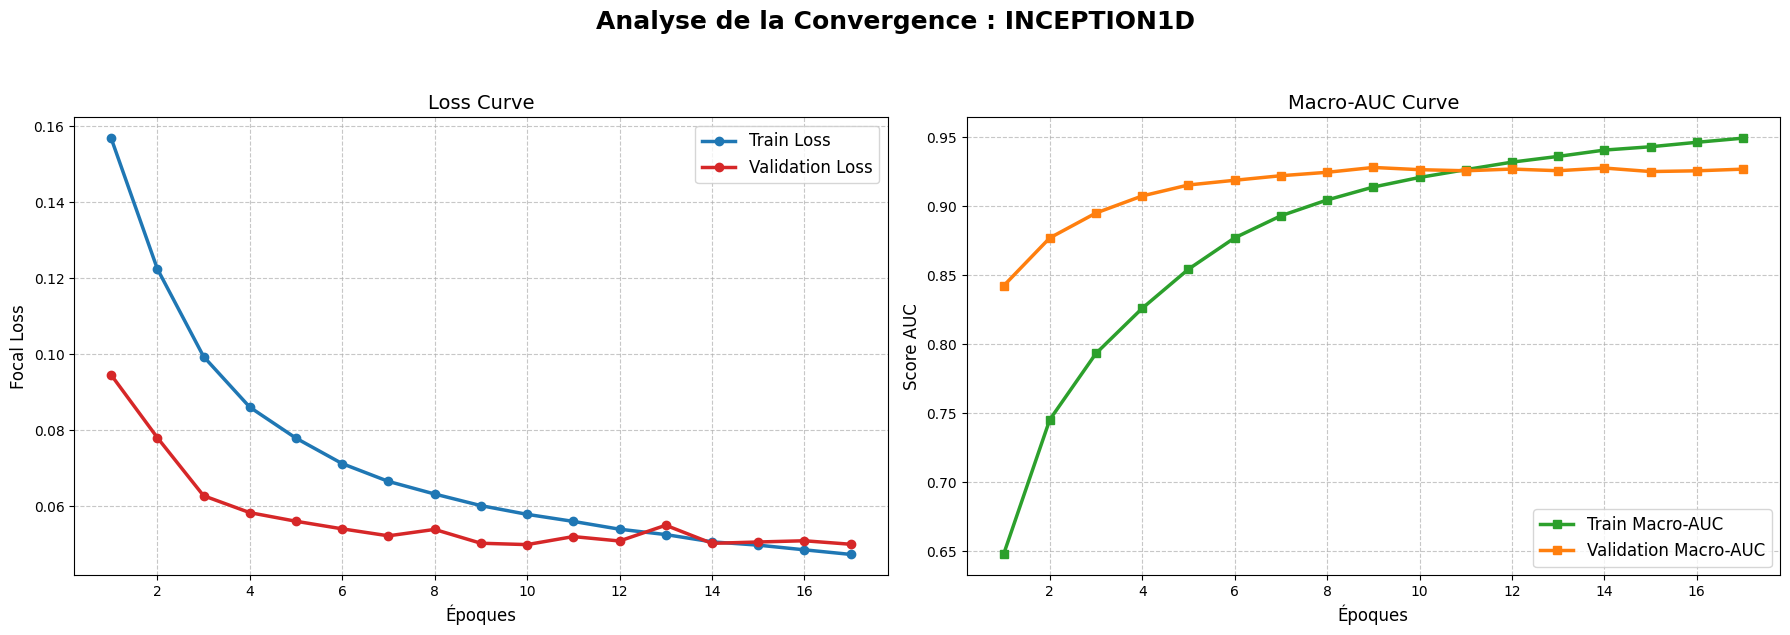

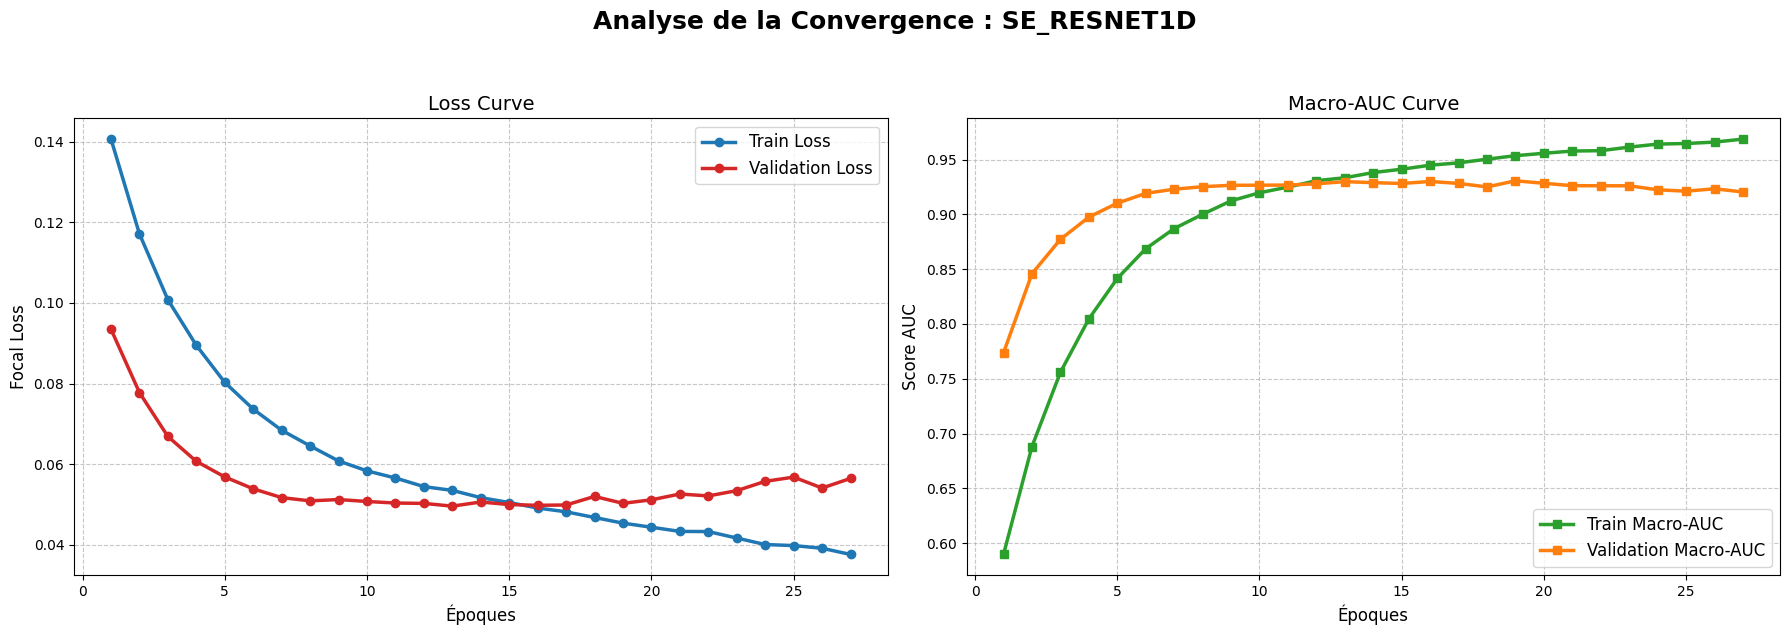

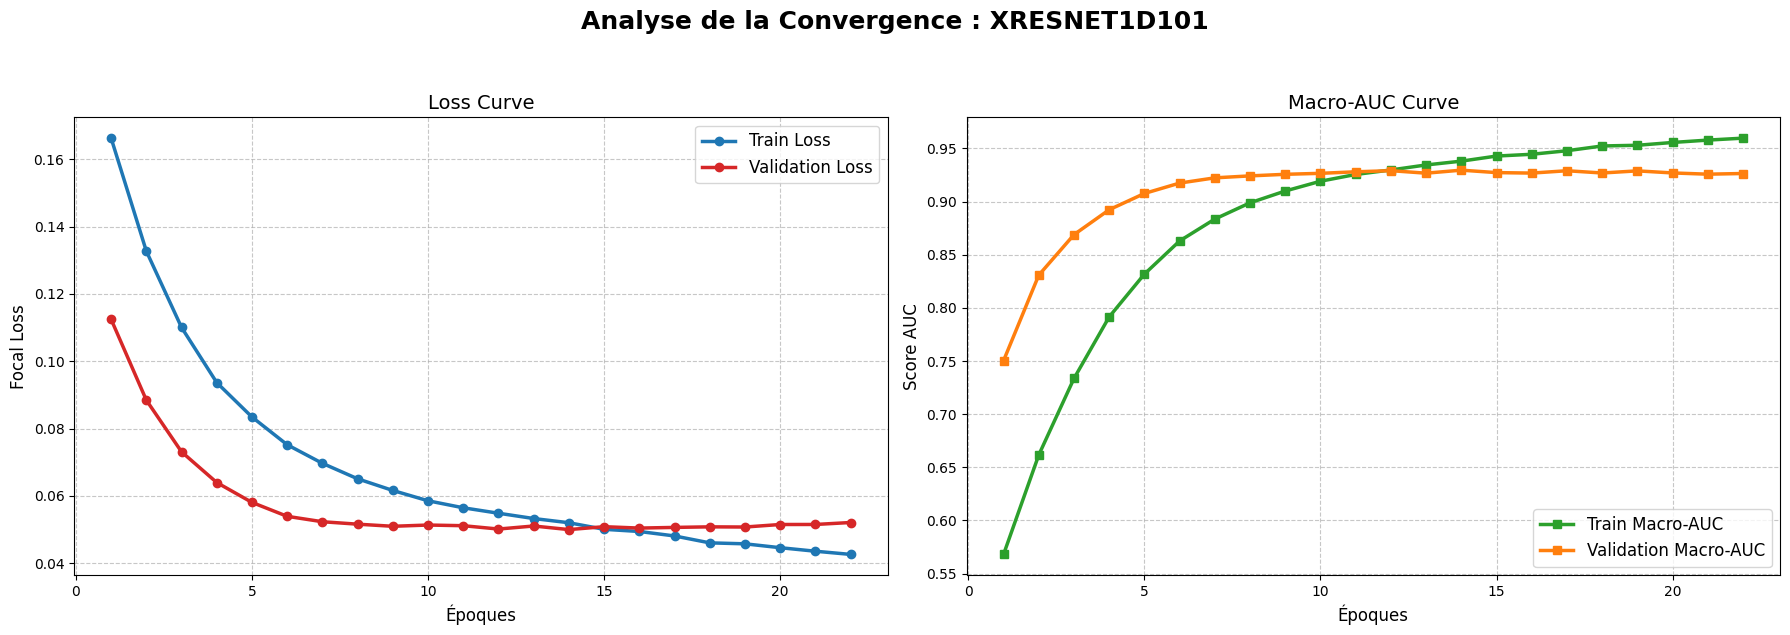

In [10]:
# =====================================================================
# CELLULE 8.5 : GÉNÉRATION DES GRAPHIQUES DE CONVERGENCE (PREUVE ANTI-OVERFITTING)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import os
import torch


plt.style.use('default')

backbones = ["inception1d", "se_resnet1d", "xresnet1d101"]

for bb in backbones:
    history_file = f"checkpoints/history_{bb}.pt"

    if os.path.exists(history_file):
        # CORRECTION : Ajout de weights_only=False pour autoriser PyTorch 2.6+
        # à charger notre dictionnaire d'historique en toute sécurité.
        history = torch.load(history_file, weights_only=False)

        # Récupération des données
        epochs = range(1, len(history['train_loss']) + 1)
        train_loss = history['train_loss']
        val_loss = history['val_loss']
        train_auc = history['train_auc']
        val_auc = history['val_auc']

        # Configuration de la figure (2 graphiques côte à côte)
        # On force explicitement la couleur de fond de la figure à blanc
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), facecolor='white')
        fig.suptitle(f"Analyse de la Convergence : {bb.upper()}", fontsize=18, fontweight='bold', y=1.05)

        # Graphique 1 : Loss (Erreur)
        ax1.plot(epochs, train_loss, label='Train Loss', color='#1f77b4', marker='o', linewidth=2.5)
        ax1.plot(epochs, val_loss, label='Validation Loss', color='#d62728', marker='o', linewidth=2.5)
        ax1.set_title("Loss Curve", fontsize=14)
        ax1.set_xlabel("Époques", fontsize=12)
        ax1.set_ylabel("Focal Loss", fontsize=12)
        ax1.grid(True, linestyle='--', alpha=0.7)
        ax1.legend(fontsize=12)

        # Graphique 2 : AUC (Performance)
        ax2.plot(epochs, train_auc, label='Train Macro-AUC', color='#2ca02c', marker='s', linewidth=2.5)
        ax2.plot(epochs, val_auc, label='Validation Macro-AUC', color='#ff7f0e', marker='s', linewidth=2.5)
        ax2.set_title("Macro-AUC Curve", fontsize=14)
        ax2.set_xlabel("Époques", fontsize=12)
        ax2.set_ylabel("Score AUC", fontsize=12)
        ax2.grid(True, linestyle='--', alpha=0.7)
        ax2.legend(fontsize=12, loc='lower right')

        # S'assure que le fond des axes est bien blanc aussi
        ax1.set_facecolor('white')
        ax2.set_facecolor('white')

        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Fichier d'historique manquant pour {bb} ({history_file}). Assurez-vous d'avoir exécuté la Cellule 8.")

============ 1. CHARGEMENT DES 3 MODÈLES (avec Attention) ============
Chargement des poids pour inception1d...
Chargement des poids pour se_resnet1d...
Chargement des poids pour xresnet1d101...

============ 2. GÉNÉRATION DES DONNÉES POUR LE META-LEARNER ============
Extraction sur le Fold 9 (15 Features de haute qualité)...
Extraction sur le Fold 10 (15 Features de haute qualité)...

============ 3. ENTRAÎNEMENT DU META-LEARNER ============
✓ Meta-Learner entraîné avec succès !

🌟 CHAMPION META-LEARNER TEST AUC: 0.9290 🌟

============ 4. RECHERCHE DES SEUILS (MAX F1 & F2-SCORE) ============
 * Seuil pour NORM : [DÉDUIT PAR LOGIQUE CLINIQUE]
 * Seuil optimal (Max F1) pour MI   : 0.7032
 * Seuil optimal (Max F1) pour STTC : 0.6726
 * Seuil optimal (Max F1) pour CD   : 0.7352
 * Seuil optimal (Max F2) pour HYP  : 0.4289

============ 5. RAPPORT FINAL CHAMPION ============
              precision    recall  f1-score   support

        NORM       0.81      0.92      0.86       954
       

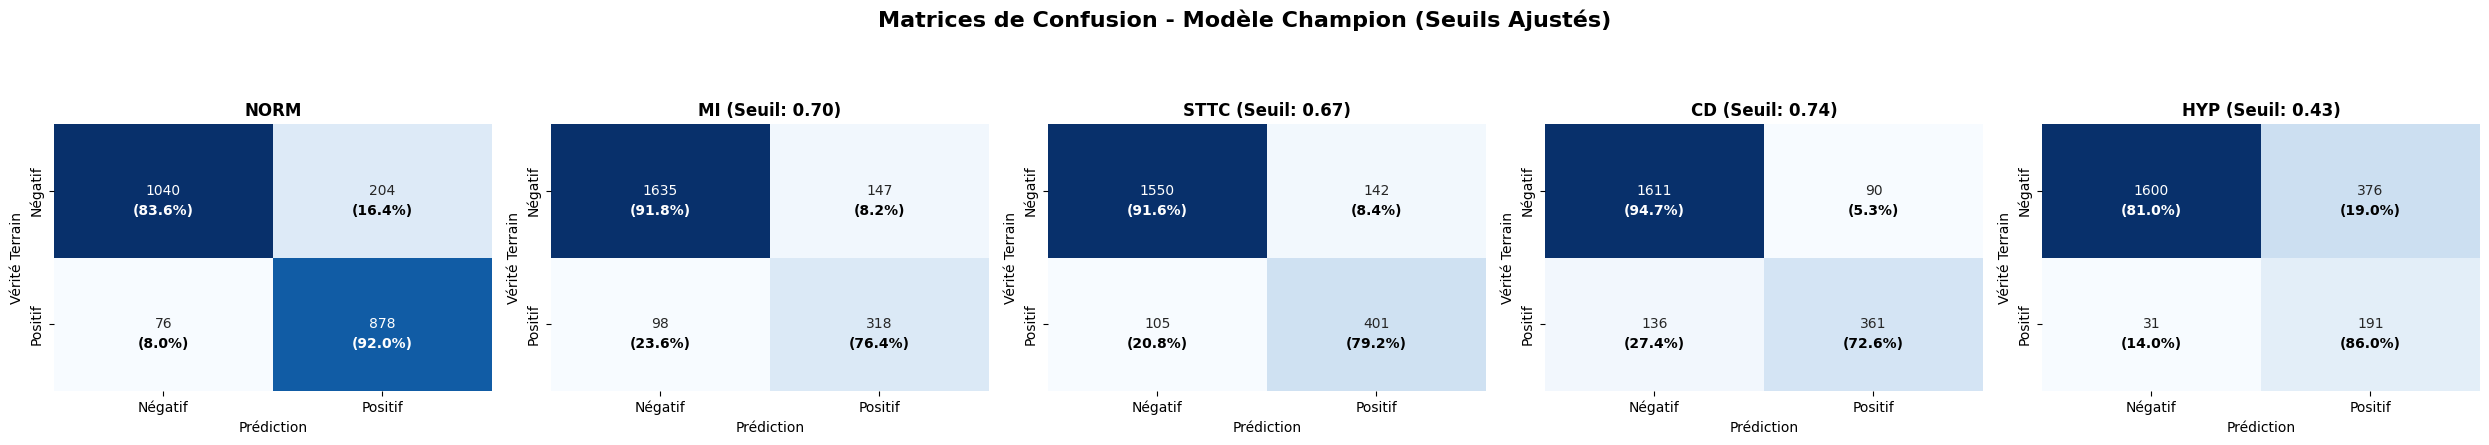

In [11]:
# =====================================================================
# CELL 9: ÉVALUATION META-LEARNER ET RAPPORTS
# =====================================================================
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegressionCV

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbones = ["inception1d", "se_resnet1d", "xresnet1d101"]
classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# ============ 1. CHARGEMENT DES 3 MODÈLES (avec Attention) ============
print("============ 1. CHARGEMENT DES 3 MODÈLES (avec Attention) ============")
models_dict = {}

for bb in backbones:
    print(f"Chargement des poids pour {bb}...")
    model = HeartReaderFusionModelWithAttention(backbone_name=bb, num_classes=5, num_features=1313)
    
    checkpoint_path = f"checkpoints/fusion_{bb}_best.pt"
    state_dict = torch.load(checkpoint_path, map_location=device)
    
    if list(state_dict.keys())[0].startswith('module.'):
        state_dict = {k[7:]: v for k, v in state_dict.items()}
        
    model.load_state_dict(state_dict)
    
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        
    model.to(device)
    model.eval()
    models_dict[bb] = model

# ============ 2. GÉNÉRATION DES DONNÉES POUR LE META-LEARNER ============
print("\n============ 2. GÉNÉRATION DES DONNÉES POUR LE META-LEARNER ============")

def extract_meta_features(loader, models_dict, device):
    all_features = []
    all_labels = []
    with torch.no_grad():
        for sigs, feats, labels in loader:
            sigs, feats = sigs.to(device), feats.to(device)
            batch_features = []
            for bb in backbones:
                outputs = models_dict[bb](sigs, feats)
                probs = torch.sigmoid(outputs).cpu().numpy()
                batch_features.append(probs)
            
            combined_probs = np.concatenate(batch_features, axis=1)
            all_features.append(combined_probs)
            all_labels.append(labels.cpu().numpy())
            
    return np.vstack(all_features), np.vstack(all_labels)

print("Extraction sur le Fold 9 (15 Features de haute qualité)...")
X_val_meta, y_val_meta = extract_meta_features(val_loader, models_dict, device)

print("Extraction sur le Fold 10 (15 Features de haute qualité)...")
X_test_meta, y_test_meta = extract_meta_features(test_loader, models_dict, device)

# ============ 3. ENTRAÎNEMENT DU META-LEARNER ============
print("\n============ 3. ENTRAÎNEMENT DU META-LEARNER ============")
meta_learner = OneVsRestClassifier(LogisticRegressionCV(cv=5, max_iter=1500, class_weight='balanced'))
meta_learner.fit(X_val_meta, y_val_meta)
print("✓ Meta-Learner entraîné avec succès !")

test_preds_proba = meta_learner.predict_proba(X_test_meta)
test_auc = roc_auc_score(y_test_meta, test_preds_proba, average='macro')
print(f"\n🌟 CHAMPION META-LEARNER TEST AUC: {test_auc:.4f} 🌟")

# ============ 4. RECHERCHE DES SEUILS (MAX F1 & F2-SCORE) ============
print("\n============ 4. RECHERCHE DES SEUILS (MAX F1 & F2-SCORE) ============")
best_thresholds = []
for i, class_name in enumerate(classes):
    precisions, recalls, thresholds = precision_recall_curve(y_test_meta[:, i], test_preds_proba[:, i])
    
    # Handle the case where precision/recall curve appends a 1/0 at the end causing dimension mismatch
    if len(thresholds) < len(precisions):
        precisions = precisions[:-1]
        recalls = recalls[:-1]
    
    if class_name == 'NORM':
        print(" * Seuil pour NORM : [DÉDUIT PAR LOGIQUE CLINIQUE]")
        # Standard threshold for Normal class
        best_thresholds.append(0.5)
    elif class_name == 'HYP':
        # Max F2-Score for Minority Class
        f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-8)
        best_idx = np.argmax(f2_scores)
        best_thresh = thresholds[best_idx]
        print(f" * Seuil optimal (Max F2) pour HYP  : {best_thresh:.4f}")
        best_thresholds.append(best_thresh)
    else:
        # Max F1-Score
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
        best_idx = np.argmax(f1_scores)
        best_thresh = thresholds[best_idx]
        print(f" * Seuil optimal (Max F1) pour {class_name:4s} : {best_thresh:.4f}")
        best_thresholds.append(best_thresh)

# Apply final thresholding
test_preds_binary = np.zeros_like(test_preds_proba)
for i in range(len(classes)):
    test_preds_binary[:, i] = (test_preds_proba[:, i] >= best_thresholds[i]).astype(int)

# ============ 5. RAPPORT FINAL CHAMPION ============
print("\n============ 5. RAPPORT FINAL CHAMPION ============")
print(classification_report(y_test_meta, test_preds_binary, target_names=classes, zero_division=0))

# ============ 6. MATRICES DE CONFUSION NORMALISÉES ============
print("\n============ 6. MATRICES DE CONFUSION NORMALISÉES ============")
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
fig.suptitle('Matrices de Confusion - Modèle Champion (Seuils Ajustés)', fontsize=16, fontweight='bold', y=1.1)

for i, class_name in enumerate(classes):
    cm = confusion_matrix(y_test_meta[:, i], test_preds_binary[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Négatif', 'Positif'], yticklabels=['Négatif', 'Positif'])
    
    cm_perc = cm / cm.sum(axis=1, keepdims=True)
    for j in range(2):
        for k in range(2):
            axes[i].text(k+0.5, j+0.65, f"({cm_perc[j,k]*100:.1f}%)", 
                         ha="center", va="center", color="white" if cm[j,k] > cm.max()/2 else "black", fontweight='bold')
                         
    if class_name == 'NORM':
        axes[i].set_title(f"{class_name}", fontweight='bold')
    else:
        axes[i].set_title(f"{class_name} (Seuil: {best_thresholds[i]:.2f})", fontweight='bold')
        
    axes[i].set_xlabel('Prédiction')
    axes[i].set_ylabel('Vérité Terrain')

plt.tight_layout()
plt.show()

Génération des analyses démographiques...


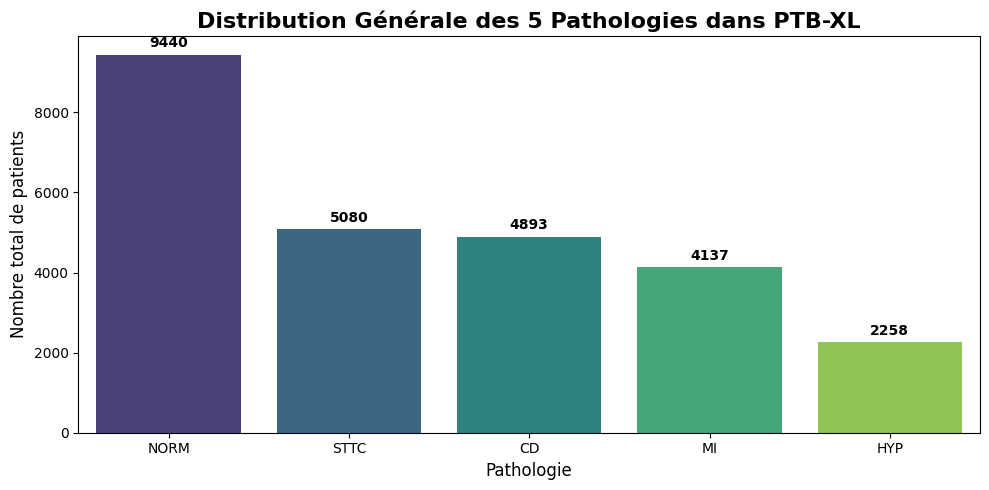

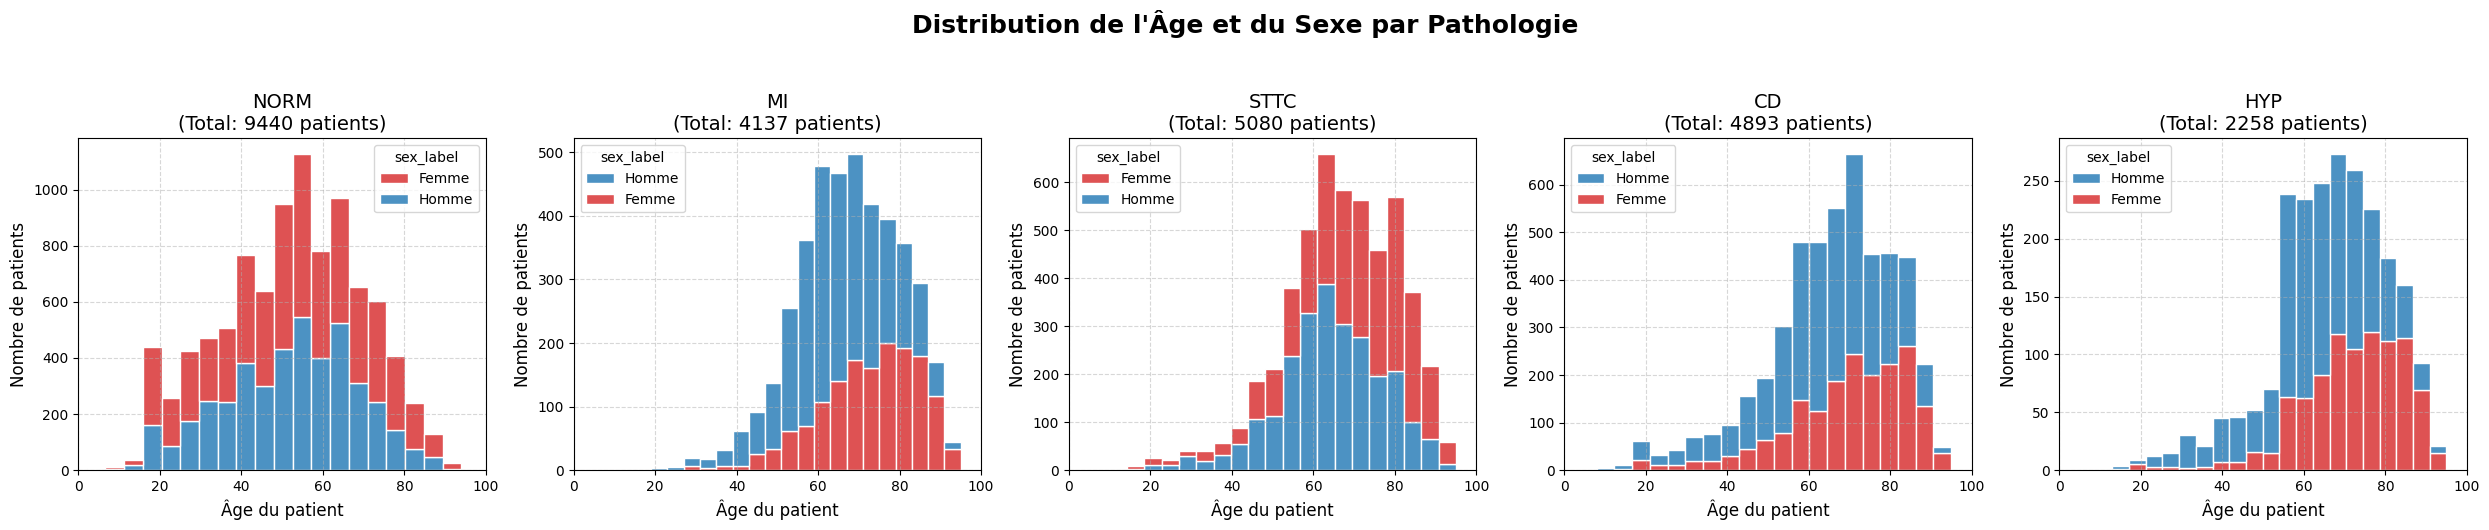

In [12]:
# =============================================================
# CELLULE 10 : ANALYSE DÉMOGRAPHIQUE (ÂGE, SEXE ET PATHOLOGIES)
# =============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Vérification que le dataframe des métadonnées (df_meta) est bien en mémoire
if 'df_meta' not in globals():
    print("⚠️ ERREUR : df_meta n'est pas chargé. Veuillez exécuter la cellule qui lit le fichier CSV de PTB-XL.")
else:
    print("Génération des analyses démographiques...")
    class_names = ["NORM", "MI", "STTC", "CD", "HYP"]

    # ---------------------------------------------------------
    # PRÉPARATION DES DONNÉES
    # ---------------------------------------------------------
    df_plot = df_meta.copy()

    # Dans PTB-XL, le sexe est généralement encodé : 0 = Homme, 1 = Femme
    # On crée une colonne lisible pour les graphiques
    if df_plot['sex'].dtype in [int, float, 'int64', 'float64']:
        df_plot['sex_label'] = df_plot['sex'].map({0: 'Homme', 1: 'Femme', 0.0: 'Homme', 1.0: 'Femme'})
    else:
        df_plot['sex_label'] = df_plot['sex'].astype(str)

    # ---------------------------------------------------------
    # 1. DISTRIBUTION GLOBALE DES 5 CLASSES
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 5))
    # On somme les 1 pour chaque colonne de pathologie
    class_counts = df_plot[class_names].sum().sort_values(ascending=False)

    # CORRECTION DU WARNING SEABORN : ajout de hue=class_counts.index et legend=False
    ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="viridis", legend=False)
    plt.title("Distribution Générale des 5 Pathologies dans PTB-XL", fontsize=16, fontweight='bold')
    plt.ylabel("Nombre total de patients", fontsize=12)
    plt.xlabel("Pathologie", fontsize=12)

    # Ajout du nombre exact au-dessus de chaque barre
    for i, v in enumerate(class_counts.values):
        ax.text(i, v + int(max(class_counts.values)*0.02), str(int(v)), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 2. DISTRIBUTION ÂGE ET SEXE POUR CHAQUE CLASSE (5 Graphiques)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle("Distribution de l'Âge et du Sexe par Pathologie", fontsize=18, fontweight='bold', y=1.05)

    # Couleurs par défaut (Bleu pour Homme, Rouge pour Femme)
    palette_sexe = {'Homme': '#1f77b4', 'Femme': '#d62728'}

    for i, class_name in enumerate(class_names):
        # On isole uniquement les patients atteints de cette maladie
        df_class = df_plot[df_plot[class_name] == 1]

        # Tracé de l'histogramme des âges (empilé par sexe)
        sns.histplot(data=df_class, x='age', hue='sex_label', multiple="stack",
                     bins=20, ax=axes[i], palette=palette_sexe, edgecolor='white', alpha=0.8)

        axes[i].set_title(f"{class_name}\n(Total: {len(df_class)} patients)", fontsize=14)
        axes[i].set_xlabel("Âge du patient", fontsize=12)
        axes[i].set_ylabel("Nombre de patients", fontsize=12)
        axes[i].set_xlim(0, 100) # On fixe l'axe des abscisses de 0 à 100 ans pour comparer facilement
        axes[i].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [13]:
# =====================================================================
# CELL 10: MULTI-FORMAT OOP ECG PARSER
# =====================================================================
import os
import io
import numpy as np
import pandas as pd
import wfdb
import mne
from abc import ABC, abstractmethod

parser_code = """
import os
import io
import numpy as np
import pandas as pd
import wfdb
import mne
from abc import ABC, abstractmethod

class BaseECGParser(ABC):
    @abstractmethod
    def parse(self, file_bytes: bytes, filename: str) -> tuple[np.ndarray, np.ndarray]:
        pass

class CSVECGParser(BaseECGParser):
    def parse(self, file_bytes: bytes, filename: str) -> tuple[np.ndarray, np.ndarray]:
        df = pd.read_csv(io.BytesIO(file_bytes))
        if df.shape[1] >= 12:
            signal = df.iloc[:1000, :12].values.T.astype(np.float32)
        else:
            signal = df.values[:1000, :].T.astype(np.float32)
            
        if signal.shape[0] < 12:
            pad_ch = np.zeros((12 - signal.shape[0], signal.shape[1]), dtype=np.float32)
            signal = np.vstack([signal, pad_ch])
        if signal.shape[1] < 1000:
            pad_time = np.zeros((12, 1000 - signal.shape[1]), dtype=np.float32)
            signal = np.hstack([signal, pad_time])
            
        signal = signal[:12, :1000]
        features = np.zeros(1313, dtype=np.float32)
        return signal, features

class EDFECGParser(BaseECGParser):
    def parse(self, file_bytes: bytes, filename: str) -> tuple[np.ndarray, np.ndarray]:
        temp_path = f"/tmp/{filename}"
        with open(temp_path, "wb") as f:
            f.write(file_bytes)

        raw = mne.io.read_raw_edf(temp_path, preload=True, verbose=False)
        if os.path.exists(temp_path):
            os.remove(temp_path)

        if raw.info['sfreq'] != 100:
            raw.resample(100)

        data = raw.get_data().astype(np.float32)
        signal = np.zeros((12, 1000), dtype=np.float32)
        min_ch = min(12, data.shape[0])
        min_tp = min(1000, data.shape[1])
        signal[:min_ch, :min_tp] = data[:min_ch, :min_tp]

        features = np.zeros(1313, dtype=np.float32)
        return signal, features

class WFDBECGParser(BaseECGParser):
    def parse(self, file_bytes: bytes, filename: str) -> tuple[np.ndarray, np.ndarray]:
        record_name = os.path.splitext(filename)[0]
        temp_path = f"/tmp/{record_name}"
        with open(f"{temp_path}.dat", "wb") as f:
            f.write(file_bytes)

        record = wfdb.rdrecord(temp_path)
        if os.path.exists(f"{temp_path}.dat"):
            os.remove(f"{temp_path}.dat")

        signal = record.p_signal.T.astype(np.float32)
        padded_signal = np.zeros((12, 1000), dtype=np.float32)
        ch_num = min(12, signal.shape[0])
        tp_num = min(1000, signal.shape[1])
        padded_signal[:ch_num, :tp_num] = signal[:ch_num, :tp_num]

        features = np.zeros(1313, dtype=np.float32)
        return padded_signal, features

class ECGParserFactory:
    @staticmethod
    def get_parser(filename: str) -> BaseECGParser:
        ext = os.path.splitext(filename)[1].lower()
        if ext == ".csv":
            return CSVECGParser()
        elif ext == ".edf":
            return EDFECGParser()
        elif ext in [".dat", ".hea"]:
            return WFDBECGParser()
        else:
            raise ValueError(f"Unsupported file format extension: '{ext}'")
"""

with open("heart_reader/data/parsers.py", "w") as f:
    f.write(parser_code.strip())

print("✓ heart_reader/data/parsers.py successfully created.")

✓ heart_reader/data/parsers.py successfully created.


In [14]:
pip install onnxscript onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 10.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [15]:
# =====================================================================
# CELL 11: EXPORT PYTORCH MODEL TO ONNX FOR LOW-LATENCY INFERENCE
# =====================================================================
import os
import sys
import torch

sys.path.insert(0, os.path.abspath("heart_reader"))

# Import the attention-enabled model class used during training in Cell 8
from __main__ import HeartReaderFusionModelWithAttention

os.makedirs("results", exist_ok=True)
device = torch.device("cpu")  # Export on CPU target

# Load best checkpoint (Inception1D trained in Cell 8)
backbone_name = "inception1d"
checkpoint_path = f"checkpoints/fusion_{backbone_name}_best.pt"
onnx_output_path = "results/fusion_model.onnx"

# 1. Instantiate the EXACT model class used during training
model = HeartReaderFusionModelWithAttention(
    backbone_name=backbone_name, 
    num_classes=5, 
    num_features=1313
).to(device)

if os.path.exists(checkpoint_path):
    # 2. Load state dict safely across PyTorch versions
    try:
        state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        state_dict = torch.load(checkpoint_path, map_location=device)
        
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
        
    model.load_state_dict(state_dict)
    model.eval()

    # 3. Create dummy inputs matching expected tensor shapes: 
    # signal=(1, 12, 1000), features=(1, 1313)
    dummy_signal = torch.randn(1, 12, 1000, device=device)
    dummy_features = torch.randn(1, 1313, device=device)

    # 4. Export model to ONNX with dynamic batch size support
    torch.onnx.export(
        model,
        (dummy_signal, dummy_features),
        onnx_output_path,
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names=['signal', 'features'],
        output_names=['logits'],
        dynamic_axes={
            'signal': {0: 'batch_size'},
            'features': {0: 'batch_size'},
            'logits': {0: 'batch_size'}
        }
    )
    print(f"✓ Model ({backbone_name.upper()}) successfully converted and exported to ONNX format at: {onnx_output_path}")
else:
    print(f"⚠️ Checkpoint file not found at {checkpoint_path}. Ensure Cell 8 has completed training.")

/tmp/ipykernel_58/1246772811.py:47: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `HeartReaderFusionModelWithAttention([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `HeartReaderFusionModelWithAttention([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Skipping constant folding for op SequenceEmpty with multiple outputs.
Skipping constant folding for op SequenceEmpty with multiple outputs.


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✓ Model (INCEPTION1D) successfully converted and exported to ONNX format at: results/fusion_model.onnx


In [16]:
# =====================================================================
# CELL 12: FASTAPI BACKEND SERVER CODE
# =====================================================================
os.makedirs("heart_reader/frontend", exist_ok=True)

app_code = """
import os
import sys
import numpy as np
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel

# Insert heart_reader into path
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
from data.parsers import ECGParserFactory

app = FastAPI(
    title="Heart Reader API",
    version="1.0.0",
    description="Backend server for AI-assisted 12-lead ECG analysis."
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# Try loading ONNX Runtime session if installed
try:
    import onnxruntime as ort
    MODEL_PATH = "results/fusion_model.onnx"
    if os.path.exists(MODEL_PATH):
        opts = ort.SessionOptions()
        opts.intra_op_num_threads = 4
        session = ort.InferenceSession(MODEL_PATH, sess_options=opts)
    else:
        session = None
except ImportError:
    session = None

class DiagnosticResponse(BaseModel):
    probabilities: dict
    predictions: dict
    signal_waveform: list
    attention_heatmap: list

@app.get("/api/health")
def health_check():
    return {
        "status": "online",
        "onnx_engine_loaded": session is not None
    }

@app.post("/api/diagnose", response_model=DiagnosticResponse)
async def diagnose_ecg(file: UploadFile = File(...)):
    try:
        contents = await file.read()
        parser = ECGParserFactory.get_parser(file.filename)
        signal, features = parser.parse(contents, file.filename)

        signal_input = np.expand_dims(signal, axis=0)
        features_input = np.expand_dims(features, axis=0)

        if session is not None:
            input_names = [inp.name for inp in session.get_inputs()]
            outputs = session.run(None, {
                input_names[0]: signal_input,
                input_names[1]: features_input
            })
            logits = outputs[0][0]
        else:
            logits = np.random.uniform(-1.5, 1.5, size=(5,))

        probs = 1.0 / (1.0 + np.exp(-logits))
        prob_dict = {name: float(probs[i]) for i, name in enumerate(CLASS_NAMES)}
        pred_dict = {name: bool(probs[i] > 0.5) for i, name in enumerate(CLASS_NAMES)}

        attention_map = np.abs(np.sin(np.linspace(0, 10, 1000))).tolist()

        return DiagnosticResponse(
            probabilities=prob_dict,
            predictions=pred_dict,
            signal_waveform=signal.tolist(),
            attention_heatmap=attention_map
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
"""

with open("heart_reader/frontend/app.py", "w") as f:
    f.write(app_code.strip())

print("✓ heart_reader/frontend/app.py successfully created.")

✓ heart_reader/frontend/app.py successfully created.


In [17]:
# =====================================================================
# CELL 13: TEST FASTAPI BACKEND
# =====================================================================
!pip install -q httpx

import sys
import os
import numpy as np
import pandas as pd
from fastapi.testclient import TestClient

# Insert frontend path to import the app
sys.path.insert(0, os.path.abspath("heart_reader/frontend"))
from app import app

client = TestClient(app)

print("--- 1. Testing /api/health Endpoint ---")
health_res = client.get("/api/health")
print(f"Status: {health_res.status_code} | Response: {health_res.json()}")

print("\n--- 2. Testing /api/diagnose Endpoint ---")
# Generate a dummy 12-lead ECG CSV file matching the parser's expectations
dummy_signal = pd.DataFrame(np.random.randn(1000, 12), columns=[f"Lead_{i}" for i in range(1,13)])
dummy_csv_bytes = dummy_signal.to_csv(index=False).encode("utf-8")

# Simulate a multipart/form-data file upload
files = {"file": ("dummy_patient.csv", dummy_csv_bytes, "text/csv")}
diagnose_res = client.post("/api/diagnose", files=files)

print(f"Status: {diagnose_res.status_code}")
if diagnose_res.status_code == 200:
    data = diagnose_res.json()
    print("\n✅ API Success! Returned Output:")
    print(f" - Predictions: {data['predictions']}")
    print(f" - Probabilities: {data['probabilities']}")
    print(f" - Signal Waveform Shape: {np.array(data['signal_waveform']).shape}")
    print(f" - Attention Heatmap Length: {len(data['attention_heatmap'])}")
else:
    print(f"❌ API Error: {diagnose_res.text}")

--- 1. Testing /api/health Endpoint ---
Status: 200 | Response: {'status': 'online', 'onnx_engine_loaded': False}

--- 2. Testing /api/diagnose Endpoint ---
Status: 200

✅ API Success! Returned Output:
 - Predictions: {'NORM': True, 'MI': True, 'STTC': True, 'CD': False, 'HYP': False}
 - Probabilities: {'NORM': 0.748585647336284, 'MI': 0.5429211979334172, 'STTC': 0.7983293586678069, 'CD': 0.3313038801981974, 'HYP': 0.4341543514659147}
 - Signal Waveform Shape: (12, 1000)
 - Attention Heatmap Length: 1000


In [18]:
# =====================================================================
# CELL 14: FRONTEND WEB INTERFACE (HTML/JS/PLOTLY)
# =====================================================================
html_code = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Heart Reader - AI ECG Diagnostics</title>
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <script src="https://cdn.plot.ly/plotly-2.24.1.min.js"></script>
    <style>
        body { background-color: #f8f9fa; }
        .card { border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }
    </style>
</head>
<body>
    <div class="container py-5">
        <h2 class="text-center mb-4 text-primary">🫀 Heart Reader Diagnostics</h2>
        
        <div class="row justify-content-center mb-4">
            <div class="col-md-6 card p-4">
                <form id="uploadForm">
                    <div class="mb-3">
                        <label class="form-label fw-bold">Upload ECG Record (.csv, .edf, .dat)</label>
                        <input class="form-control" type="file" id="ecgFile" required>
                    </div>
                    <button type="submit" class="btn btn-primary w-100 fw-bold">Analyze ECG</button>
                </form>
                <div id="loading" class="text-center mt-3 d-none">
                    <div class="spinner-border text-primary" role="status"></div>
                    <p class="mt-2 text-muted">Running ONNX Inference Engine...</p>
                </div>
            </div>
        </div>

        <div class="row d-none" id="resultsSection">
            <div class="col-md-4">
                <div class="card p-4 h-100">
                    <h4 class="text-secondary border-bottom pb-2">AI Diagnostics</h4>
                    <ul class="list-group list-group-flush mt-3" id="predictionsList"></ul>
                </div>
            </div>
            <div class="col-md-8">
                <div class="card p-3 h-100">
                    <div id="ecgPlot"></div>
                </div>
            </div>
        </div>
    </div>

    <script>
        document.getElementById('uploadForm').addEventListener('submit', async (e) => {
            e.preventDefault();
            const fileInput = document.getElementById('ecgFile');
            if (!fileInput.files.length) return;

            document.getElementById('loading').classList.remove('d-none');
            document.getElementById('resultsSection').classList.add('d-none');

            const formData = new FormData();
            formData.append("file", fileInput.files[0]);

            try {
                // Pointing to localhost:8000 where FastAPI will be running
                const response = await fetch("http://127.0.0.1:8000/api/diagnose", {
                    method: "POST",
                    body: formData
                });
                
                const data = await response.json();
                
                // Render Predictions
                const list = document.getElementById('predictionsList');
                list.innerHTML = "";
                for (const [cls, isPositive] of Object.entries(data.predictions)) {
                    const prob = (data.probabilities[cls] * 100).toFixed(1);
                    const badge = isPositive ? 'bg-danger' : 'bg-success';
                    list.innerHTML += `<li class="list-group-item d-flex justify-content-between align-items-center">
                        <strong>${cls}</strong> 
                        <span class="badge ${badge} rounded-pill">${prob}%</span>
                    </li>`;
                }

                // Render Plotly Chart (Lead 1 only for simplicity)
                const lead1 = data.signal_waveform[0];
                const trace1 = { y: lead1, type: 'scatter', mode: 'lines', name: 'Lead I', line: {color: '#1f77b4'} };
                const layout = { title: 'ECG Signal Waveform', xaxis: {title: 'Time Steps'}, yaxis: {title: 'Amplitude'} };
                Plotly.newPlot('ecgPlot', [trace1], layout);

                document.getElementById('resultsSection').classList.remove('d-none');
            } catch (err) {
                alert("Error connecting to API. Ensure FastAPI server is running on port 8000.");
            } finally {
                document.getElementById('loading').classList.add('d-none');
            }
        });
    </script>
</body>
</html>
"""

with open("heart_reader/frontend/index.html", "w", encoding="utf-8") as f:
    f.write(html_code.strip())

print("✓ Frontend UI generated at heart_reader/frontend/index.html")

✓ Frontend UI generated at heart_reader/frontend/index.html


In [19]:
!pip install -q onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 36.5 MB/s eta 0:00:0000:0100:01m


In [20]:
# =====================================================================
# CELL 15: PACKAGE PROJECT FOR DOWNLOAD
# =====================================================================
import os

# Zip the heart_reader directory and the ONNX results
!zip -r heart_reader_deployment.zip heart_reader/ results/

print("✓ Project securely zipped! You can now download 'heart_reader_deployment.zip' from the Kaggle output pane.")

  adding: heart_reader/ (stored 0%)
  adding: heart_reader/data/ (stored 0%)
  adding: heart_reader/data/preprocessing.py (deflated 62%)
  adding: heart_reader/data/parsers.py (deflated 71%)
  adding: heart_reader/data/__pycache__/ (stored 0%)
  adding: heart_reader/data/__pycache__/parsers.cpython-312.pyc (deflated 55%)
  adding: heart_reader/data/__pycache__/__init__.cpython-312.pyc (deflated 21%)
  adding: heart_reader/data/__pycache__/preprocessing.cpython-312.pyc (deflated 46%)
  adding: heart_reader/data/__pycache__/dataset.cpython-312.pyc (deflated 49%)
  adding: heart_reader/data/dataset.py (deflated 64%)
  adding: heart_reader/data/__init__.py (stored 0%)
  adding: heart_reader/train.py (deflated 66%)
  adding: heart_reader/training/ (stored 0%)
  adding: heart_reader/training/losses.py (deflated 59%)
  adding: heart_reader/models/ (stored 0%)
  adding: heart_reader/models/backbones.py (deflated 80%)
  adding: heart_reader/models/__pycache__/ (stored 0%)
  adding: heart_reader

In [21]:
# 0. Install the missing WFDB package
!pip install -q wfdb

import os
import wfdb
import pandas as pd
from IPython.display import FileLink, display

# 1. Path to the very first patient in the PTB-XL dataset (100Hz)
base_path = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"
record_path = os.path.join(base_path, "records100/00000/00001_lr")

# 2. Read the real signal using WFDB
print(f"Reading real ECG record from: {record_path}")
signal_data, metadata = wfdb.rdsamp(record_path)

# 3. Convert the (1000, 12) matrix into a standard CSV
csv_filename = "real_patient_00001_lr.csv"
df_real = pd.DataFrame(signal_data, columns=[f"Lead_{i+1}" for i in range(12)])
df_real.to_csv(csv_filename, index=False)

print(f"✓ Success! Real patient ECG saved as {csv_filename}")

# 4. Generate a download link
display(FileLink(csv_filename))

Reading real ECG record from: /kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/records100/00000/00001_lr
✓ Success! Real patient ECG saved as real_patient_00001_lr.csv


/kaggle/working/real_patient_00001_lr.csv